## Linar regression

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = {
    "Experience_Years": [0, 1, 2, 3, 4, 5, 6, 7, 8],
    "Salary_USD": [30000, 35000, 40000, 48000, 55000, 63000, 72000, 82000, 92000]
}

df = pd.DataFrame(data)
print(df)

   Experience_Years  Salary_USD
0                 0       30000
1                 1       35000
2                 2       40000
3                 3       48000
4                 4       55000
5                 5       63000
6                 6       72000
7                 7       82000
8                 8       92000


<Axes: xlabel='Experience_Years', ylabel='Salary_USD'>

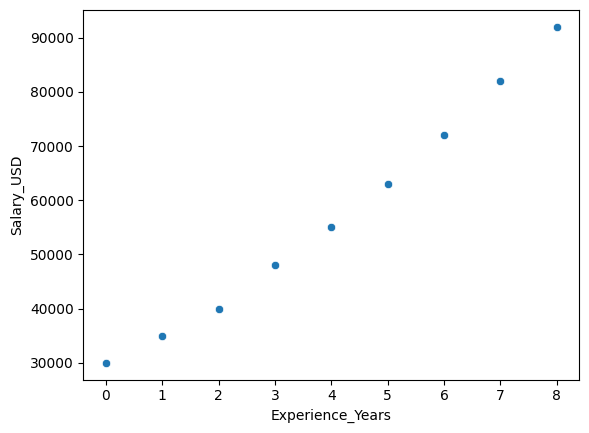

In [3]:
sns.scatterplot(x="Experience_Years", y="Salary_USD", data=df)

In [4]:
avgsal=np.average(df["Salary_USD"])

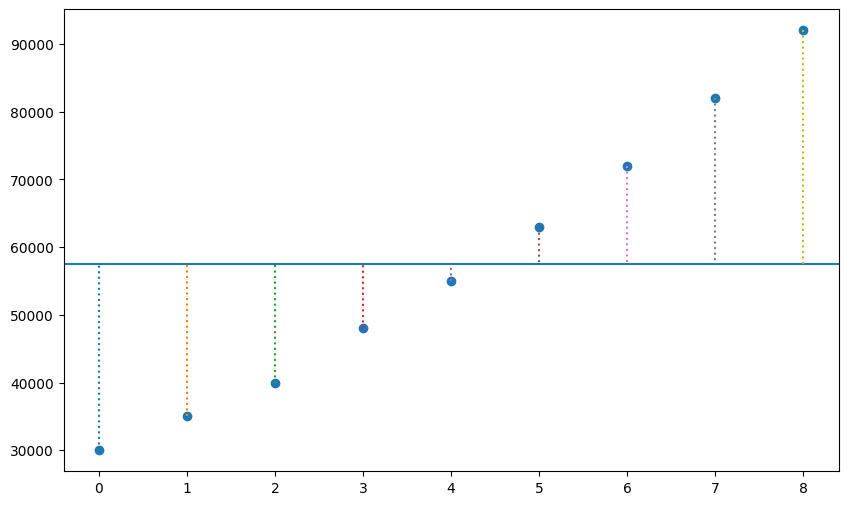

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Experience_Years"],df["Salary_USD"], label="Data Points")
plt.axhline(avgsal)
for x, y in zip(df["Experience_Years"], df["Salary_USD"]):
    plt.plot(
        [x, x],                 # same x
        [y,avgsal],        # from point to mean line
        linestyle='dotted'
    )


In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

X = df["Experience_Years"].values.reshape(-1, 1)
y = df["Salary_USD"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 3881242.568370971
R-squared: 0.9611875743162903


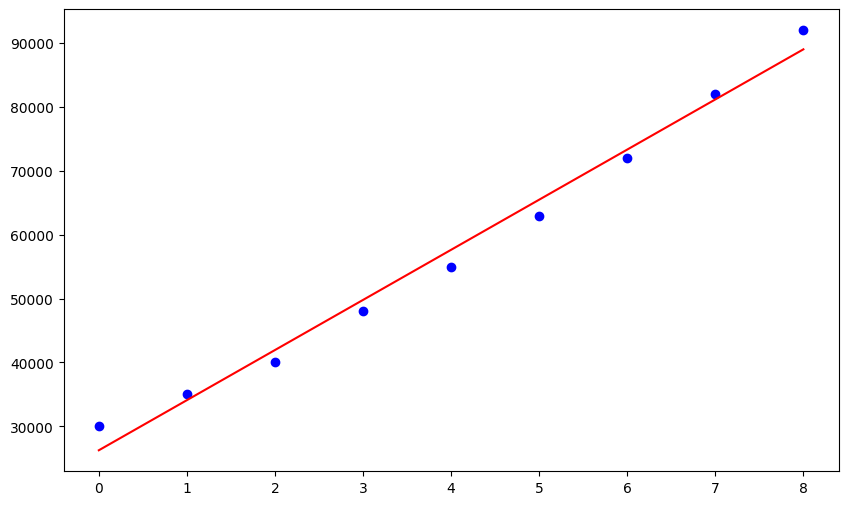

In [7]:
plt.figure(figsize=(10, 6))
plt.scatter(df["Experience_Years"], df["Salary_USD"], color='blue', label='Data Points')
plt.plot(df["Experience_Years"], model.predict(X), color='red', label='Regression Line')

## Multiple linear regression 

In [8]:

data = {
    'Size':  [8, 8.5, 9, 9.5, 10, 10.5, 11, 11.5, 12, 12.5],
    'Tail':  [7.5, 7.8, 8, 8.3, 8.5, 8.9, 9.1, 9.4, 9.8, 10.1],
    'Weight':[25, 27, 30, 32, 35, 38, 40, 43, 46, 50]
}

df = pd.DataFrame(data)
print(df)


   Size  Tail  Weight
0   8.0   7.5      25
1   8.5   7.8      27
2   9.0   8.0      30
3   9.5   8.3      32
4  10.0   8.5      35
5  10.5   8.9      38
6  11.0   9.1      40
7  11.5   9.4      43
8  12.0   9.8      46
9  12.5  10.1      50


In [9]:
X = df[['Size', 'Tail']]
y = df['Weight']


In [10]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
multimodel = LinearRegression()

In [11]:
multimodel.fit(x_train, y_train)
y_pred= multimodel.predict(x_test)
y_pred_train=multimodel.predict(x_train)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
r21=r2_score(y_train, y_pred_train)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("R-squared for training data:", r21)


Mean Squared Error: 0.6201970977175444
R-squared: 0.9931280099975895
R-squared for training data: 0.9980007963803892


## Polynomial regression 

In [12]:
data = {
    'Experience': [1,2,3,4,5,6,7,8],
    'SkillScore': [3,4,5,6,7,8,9,10],
    'Salary_USD': [35000,40000,50000,60000,65000,70000,75000,85000]
}

df3 = pd.DataFrame(data)
df3.head()

,Experience,SkillScore,Salary_USD
0,1,3,35000
1,2,4,40000
2,3,5,50000
3,4,6,60000
4,5,7,65000


In [13]:
x=df3[['Experience','SkillScore']]
y=df3['Salary_USD']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [17]:
from sklearn.preprocessing import PolynomialFeatures
poly= PolynomialFeatures(degree=2)
x_traiin_poly= poly.fit_transform(x_train)
x_test_poly= poly.transform(x_test)


In [18]:
model =LinearRegression()
model.fit(x_traiin_poly, y_train)
y_train_pred =model.predict(x_traiin_poly)
y_test_pred =model.predict(x_test_poly)
mse = mean_squared_error(y_test, y_test_pred)
r2 = r2_score(y_test, y_test_pred)
r21=r2_score(y_train, y_train_pred)
print("Mean Squared Error:", mse)
print("R-squared:", r2)
print("R-squared for training data:", r21)

Mean Squared Error: 6125739.644970434
R-squared: 0.9727744904667981
R-squared for training data: 0.9912469635627531


Text(0, 0.5, 'Salary_USD')

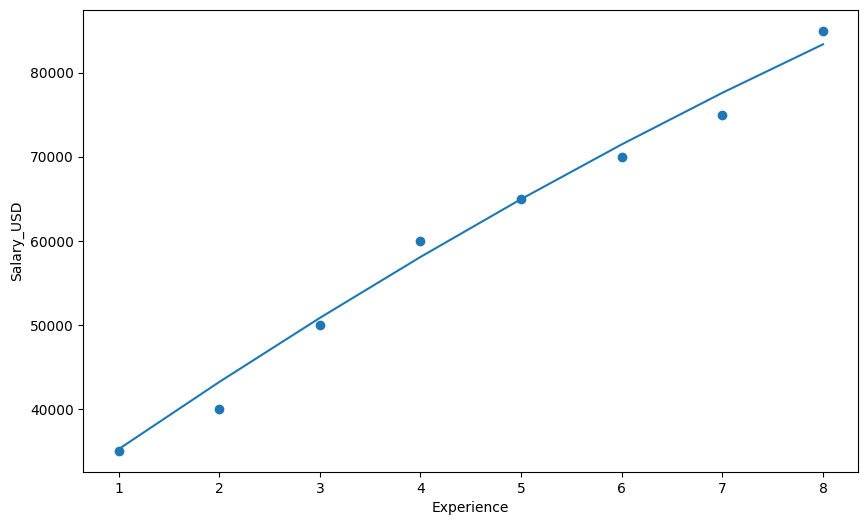

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(df3['Experience'],df3['Salary_USD'], label="Data Points")
plt.plot(df3['Experience'],model.predict(poly.transform(df3[['Experience','SkillScore']])), label="Polynomial Regression Line")
plt.xlabel('Experience')
plt.ylabel('Salary_USD')
